## Color Quantification

In [1]:
import cv2
import numpy as np
import glob
import os

# 1. 初始化路徑與參數
image_dir = '../Segmentation/Inference/petal_only_outputs/petal_cutouts/' 
image_paths = sorted(glob.glob(os.path.join(image_dir, '*.png')))
output_dir = './Pigment'
os.makedirs(output_dir, exist_ok=True)

num_samples_per_image = 1000 
voxel_size = 10               
max_per_voxel = 10         

print(f"[*] [Cell 1] 開始處理 {len(image_paths)} 張影像的特徵萃取...")

# 2. Voxel Grid 函數
def voxel_grid_downsample(pixels_lab, pixels_rgb, voxel_size, max_per_voxel):
    quantized_coords = np.floor(pixels_lab / voxel_size).astype(np.int32)
    unique_voxels, inverse_indices = np.unique(quantized_coords, axis=0, return_inverse=True)
    sampled_lab, sampled_rgb = [], []
    for i in range(len(unique_voxels)):
        in_voxel_idx = np.where(inverse_indices == i)[0]
        chosen_idx = np.random.choice(in_voxel_idx, max_per_voxel, replace=False) if len(in_voxel_idx) > max_per_voxel else in_voxel_idx
        sampled_lab.extend(pixels_lab[chosen_idx])
        sampled_rgb.extend(pixels_rgb[chosen_idx])
    return np.array(sampled_lab), np.array(sampled_rgb)

# 3. 雙重過濾與資料收集
global_pixels_lab, global_pixels_rgb = [], []

for img_path in image_paths:
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
    
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    a_channel = img_lab[:,:,1].astype(np.float32) - 128
    b_channel = img_lab[:,:,2].astype(np.float32) - 128
    chroma = np.sqrt(a_channel**2 + b_channel**2)
    l_channel = img_lab[:,:,0]
    
    valid_mask = (l_channel > 15) & (chroma > 10) 
    valid_pixels_lab = img_lab[valid_mask]
    valid_pixels_rgb = img_rgb[valid_mask]
    
    if len(valid_pixels_lab) > num_samples_per_image:
        indices = np.random.choice(len(valid_pixels_lab), num_samples_per_image, replace=False)
        global_pixels_lab.extend(valid_pixels_lab[indices])
        global_pixels_rgb.extend(valid_pixels_rgb[indices])
    else:
        global_pixels_lab.extend(valid_pixels_lab)
        global_pixels_rgb.extend(valid_pixels_rgb)

# 4. 執行降採樣與存檔
print("[*] 正在執行 Voxel Grid 降採樣...")
balanced_lab, balanced_rgb = voxel_grid_downsample(
    np.array(global_pixels_lab), np.array(global_pixels_rgb), voxel_size, max_per_voxel
)

np.save(os.path.join(output_dir, "balanced_lab.npy"), balanced_lab)
np.save(os.path.join(output_dir, "balanced_rgb.npy"), balanced_rgb)

print(f"[✔] 成功！萃取出 {len(balanced_lab)} 個特徵點，已安全存入 {output_dir}/balanced_lab.npy")
# 💡 從現在開始，如果後面的 Cell 跑錯，都不用再跑 Cell 1 了！

[*] [Cell 1] 開始處理 189 張影像的特徵萃取...
[*] 正在執行 Voxel Grid 降採樣...
[✔] 成功！萃取出 12091 個特徵點，已安全存入 ./Pigment/balanced_lab.npy


[*] [Cell 1.5] 正在生成降採樣前後 (Before vs. After) 色彩分佈對比圖...


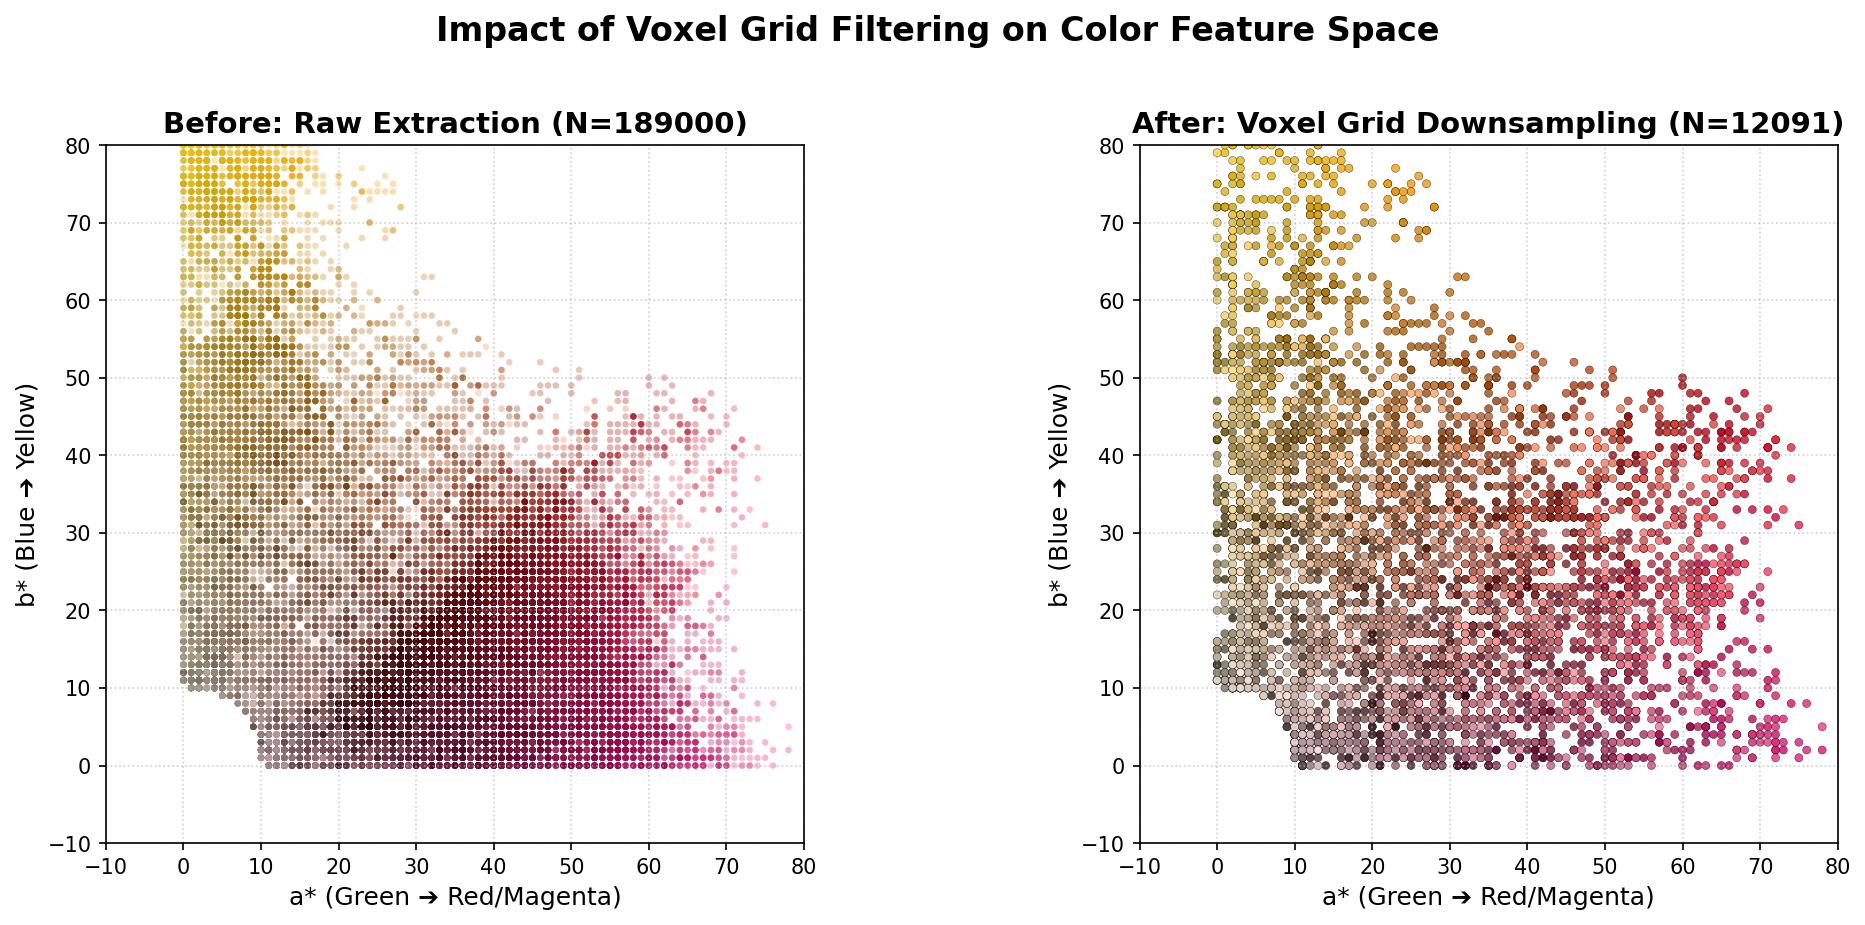

[✔] 繪圖完成！超讚的對比圖已存為 ./Pigment/01.5_Before_After_Comparison.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

output_dir = './Pigment'

print("[*] [Cell 1.5] 正在生成降採樣前後 (Before vs. After) 色彩分佈對比圖...")

# 確保 Jupyter 記憶體中還有 Cell 1 跑完的變數
if 'global_pixels_lab' not in locals() or 'balanced_lab' not in locals():
    print("[!] 錯誤：記憶體中找不到原始資料。請確保你剛剛執行完 Cell 1 且未重啟 Kernel。")
else:
    # 🌟 關鍵修復：將 Python List 轉換為 NumPy Array，才能進行高階二維切片
    global_pixels_lab = np.array(global_pixels_lab)
    global_pixels_rgb = np.array(global_pixels_rgb)

    # 建立 1x2 的雙圖畫布
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

    # ==========================================
    # 左圖：Before (原始萃取，呈現多數決霸權)
    # ==========================================
    # 防當機抽樣機制：原始資料可能高達數十萬點，畫圖最多只畫 20000 點以保證流暢
    vis_size = min(1000000, len(global_pixels_lab))
    vis_idx = np.random.choice(len(global_pixels_lab), vis_size, replace=False)

    axes[0].scatter(global_pixels_lab[vis_idx, 1] - 128, global_pixels_lab[vis_idx, 2] - 128, 
                    c=global_pixels_rgb[vis_idx]/255.0, 
                    s=10, alpha=0.3, edgecolors='none')
    
    axes[0].set_title(f"Before: Raw Extraction (N={len(global_pixels_lab)})", fontweight='bold', fontsize=14)
    axes[0].set_xlabel("a* (Green ➔ Red/Magenta)", fontsize=12)
    axes[0].set_ylabel("b* (Blue ➔ Yellow)", fontsize=12)
    axes[0].set_xlim(-60, 80)
    axes[0].set_ylim(-60, 80)
    axes[0].set_aspect('equal') # 確保長寬比例一致，色彩空間不變形
    axes[0].grid(True, linestyle=':', alpha=0.6)

    # ==========================================
    # 右圖：After (網格降採樣後，稀有色被保護)
    # ==========================================
    axes[1].scatter(balanced_lab[:, 1] - 128, balanced_lab[:, 2] - 128, 
                    c=balanced_rgb/255.0, 
                    s=15, alpha=0.8, edgecolors='k', linewidth=0.2) # 加上黑邊讓點更銳利
    
    axes[1].set_title(f"After: Voxel Grid Downsampling (N={len(balanced_lab)})", fontweight='bold', fontsize=14)
    axes[1].set_xlabel("a* (Green ➔ Red/Magenta)", fontsize=12)
    axes[1].set_ylabel("b* (Blue ➔ Yellow)", fontsize=12)
    axes[0].set_xlim(-10, 80)
    axes[0].set_ylim(-10, 80)
    axes[1].set_xlim(-10, 80)
    axes[1].set_ylim(-10, 80)
    axes[1].set_aspect('equal')
    axes[1].grid(True, linestyle=':', alpha=0.6)

    # ==========================================
    # 標題與存檔
    # ==========================================
    plt.suptitle("Impact of Voxel Grid Filtering on Color Feature Space", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # 存檔至 Pigment 資料夾
    save_path = os.path.join(output_dir, "01.5_Before_After_Comparison.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    
    print(f"[✔] 繪圖完成！超讚的對比圖已存為 {save_path}")

[*] [Cell 2] 讀取平衡後的特徵資料...
[*] 開始計算 SSE 與 Silhouette Score ... (這可能需要幾分鐘)
  ▶ K= 2 | SSE: 27,888,848 | Silhouette: 0.4003
  ▶ K= 3 | SSE: 20,557,454 | Silhouette: 0.3295
  ▶ K= 4 | SSE: 16,020,090 | Silhouette: 0.3269
  ▶ K= 5 | SSE: 13,412,520 | Silhouette: 0.3172
  ▶ K= 6 | SSE: 11,675,037 | Silhouette: 0.3003
  ▶ K= 7 | SSE: 10,455,940 | Silhouette: 0.2876
  ▶ K= 8 | SSE: 9,414,415 | Silhouette: 0.2982
  ▶ K= 9 | SSE: 8,532,514 | Silhouette: 0.2971
  ▶ K=10 | SSE: 7,885,025 | Silhouette: 0.2861
  ▶ K=11 | SSE: 7,314,077 | Silhouette: 0.2859
  ▶ K=12 | SSE: 6,839,974 | Silhouette: 0.2888
  ▶ K=13 | SSE: 6,446,496 | Silhouette: 0.2911
  ▶ K=14 | SSE: 6,097,814 | Silhouette: 0.2859
  ▶ K=15 | SSE: 5,783,013 | Silhouette: 0.2733

[💡] Kneedle 偵測 Elbow Point: K = 6
[💡] Silhouette 最高峰: K = 2


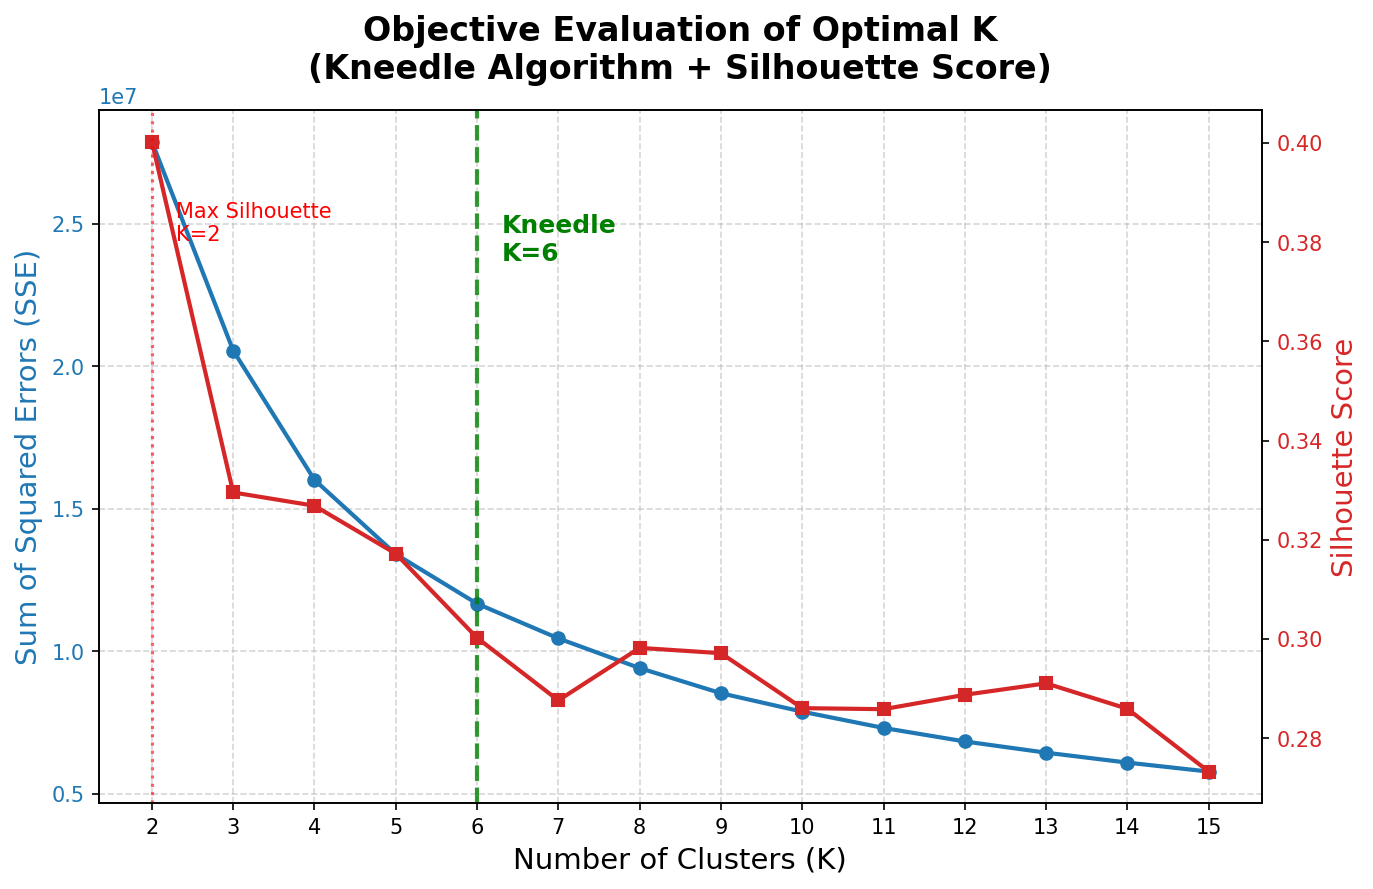


[✔] 建議使用 K = 6 (Kneedle 演算法客觀偵測)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import os

output_dir = './Pigment'

# 1. 讀取 Cell 1 存下來的資料
print("[*] [Cell 2] 讀取平衡後的特徵資料...")
balanced_lab = np.load(os.path.join(output_dir, "balanced_lab.npy"))

# 2. 測試 K=2 到 K=15
k_range = list(range(2, 16))
sse, sil_scores = [], []

print(f"[*] 開始計算 SSE 與 Silhouette Score ... (這可能需要幾分鐘)")
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans_test.fit_predict(balanced_lab)
    
    sse.append(kmeans_test.inertia_)
    score = silhouette_score(balanced_lab, labels, sample_size=5000, random_state=42)
    sil_scores.append(score)
    print(f"  ▶ K={k:2d} | SSE: {kmeans_test.inertia_:,.0f} | Silhouette: {score:.4f}")

# 3. Kneedle 演算法自動偵測 Elbow Point
kn = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
optimal_k_kneedle = kn.knee
optimal_k_sil = k_range[np.argmax(sil_scores)]

print(f"\n[💡] Kneedle 偵測 Elbow Point: K = {optimal_k_kneedle}")
print(f"[💡] Silhouette 最高峰: K = {optimal_k_sil}")

# 印出 Kneedle line distance (供論文引用)
if hasattr(kn, 'all_knees_y') and hasattr(kn, 'all_norm_distances'):
    for k_val, dist in zip(k_range, kn.y_difference):
        print(f"  K={k_val:2d} | Kneedle line distance: {dist:.4f}")

# 4. 繪製三合一圖表
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)

# SSE (左軸)
ax1.set_xlabel('Number of Clusters (K)', fontsize=14)
ax1.set_ylabel('Sum of Squared Errors (SSE)', color='tab:blue', fontsize=14)
ax1.plot(k_range, sse, marker='o', color='tab:blue', linewidth=2, label='SSE')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.5)

# Silhouette (右軸)
ax2 = ax1.twinx()  
ax2.set_ylabel('Silhouette Score', color='tab:red', fontsize=14)
ax2.plot(k_range, sil_scores, marker='s', color='tab:red', linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

# 標記 Kneedle K_opt
ax1.axvline(x=optimal_k_kneedle, color='green', linestyle='--', alpha=0.8, linewidth=2)
ax1.text(optimal_k_kneedle + 0.3, max(sse)*0.85, f'Kneedle\nK={optimal_k_kneedle}', 
         color='green', fontsize=12, fontweight='bold')

# 標記 Silhouette max
ax2.axvline(x=optimal_k_sil, color='red', linestyle=':', alpha=0.6)
ax2.text(optimal_k_sil + 0.3, max(sil_scores)*0.95, f'Max Silhouette\nK={optimal_k_sil}', 
         color='red', fontsize=10)

plt.title("Objective Evaluation of Optimal K\n(Kneedle Algorithm + Silhouette Score)", 
          fontsize=16, fontweight='bold', pad=15)
plt.savefig(os.path.join(output_dir, "02_K_Evaluation.png"), bbox_inches='tight')
plt.show()

print(f"\n[✔] 建議使用 K = {optimal_k_kneedle} (Kneedle 演算法客觀偵測)")


[*] [Cell 3] 正在使用 K=6 建立全域標準色盤...


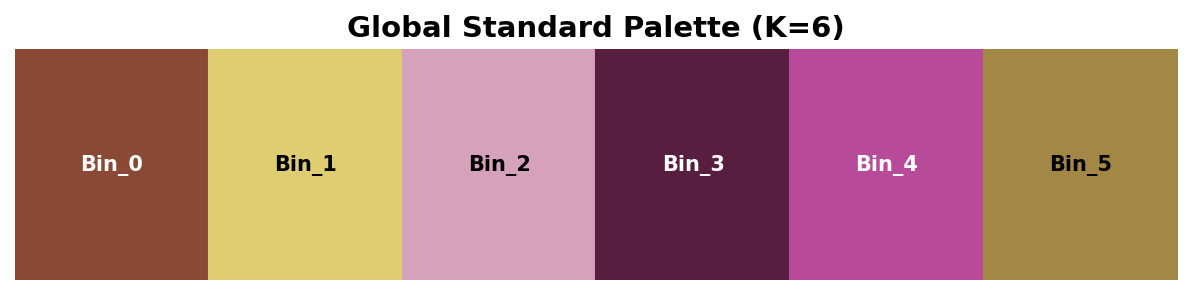

[✔] 標準色盤已鎖定並存入 ./Pigment/


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
import os

output_dir = './Pigment'
balanced_lab = np.load(os.path.join(output_dir, "balanced_lab.npy"))

# 🌟 根據 Kneedle 演算法的客觀偵測結果，設定最終的 K 值
FINAL_K = 6

print(f"[*] [Cell 3] 正在使用 K={FINAL_K} 建立全域標準色盤...")
kmeans = KMeans(n_clusters=FINAL_K, init='k-means++', n_init=10, random_state=42)
kmeans.fit(balanced_lab)
global_centers_lab = kmeans.cluster_centers_

global_centers_rgb = []
for center in global_centers_lab:
    rgb_pixel = cv2.cvtColor(np.uint8([[center]]), cv2.COLOR_LAB2RGB)[0][0]
    global_centers_rgb.append(rgb_pixel)
global_centers_rgb = np.array(global_centers_rgb)

# 將標準尺存檔
np.save(os.path.join(output_dir, "global_centers_lab.npy"), global_centers_lab)
np.save(os.path.join(output_dir, "global_centers_rgb.npy"), global_centers_rgb)

# 畫出最終色盤
fig, ax = plt.subplots(figsize=(10, 2), dpi=150)
for i, rgb in enumerate(global_centers_rgb):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=rgb/255.0))
    text_color = 'white' if (rgb[0]*0.299 + rgb[1]*0.587 + rgb[2]*0.114) < 128 else 'black'
    ax.text(i+0.5, 0.5, f"Bin_{i}", ha='center', va='center', color=text_color, fontweight='bold')

ax.set_xlim(0, FINAL_K)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title(f"Global Standard Palette (K={FINAL_K})", fontsize=14, fontweight='bold')
plt.savefig(os.path.join(output_dir, "03_global_palette.png"))
plt.show()

print(f"[✔] 標準色盤已鎖定並存入 {output_dir}/")


[*] [Cell 4] 讀取官方標準尺進行推論...
[*] 正在生成發表級表現型對照圖...


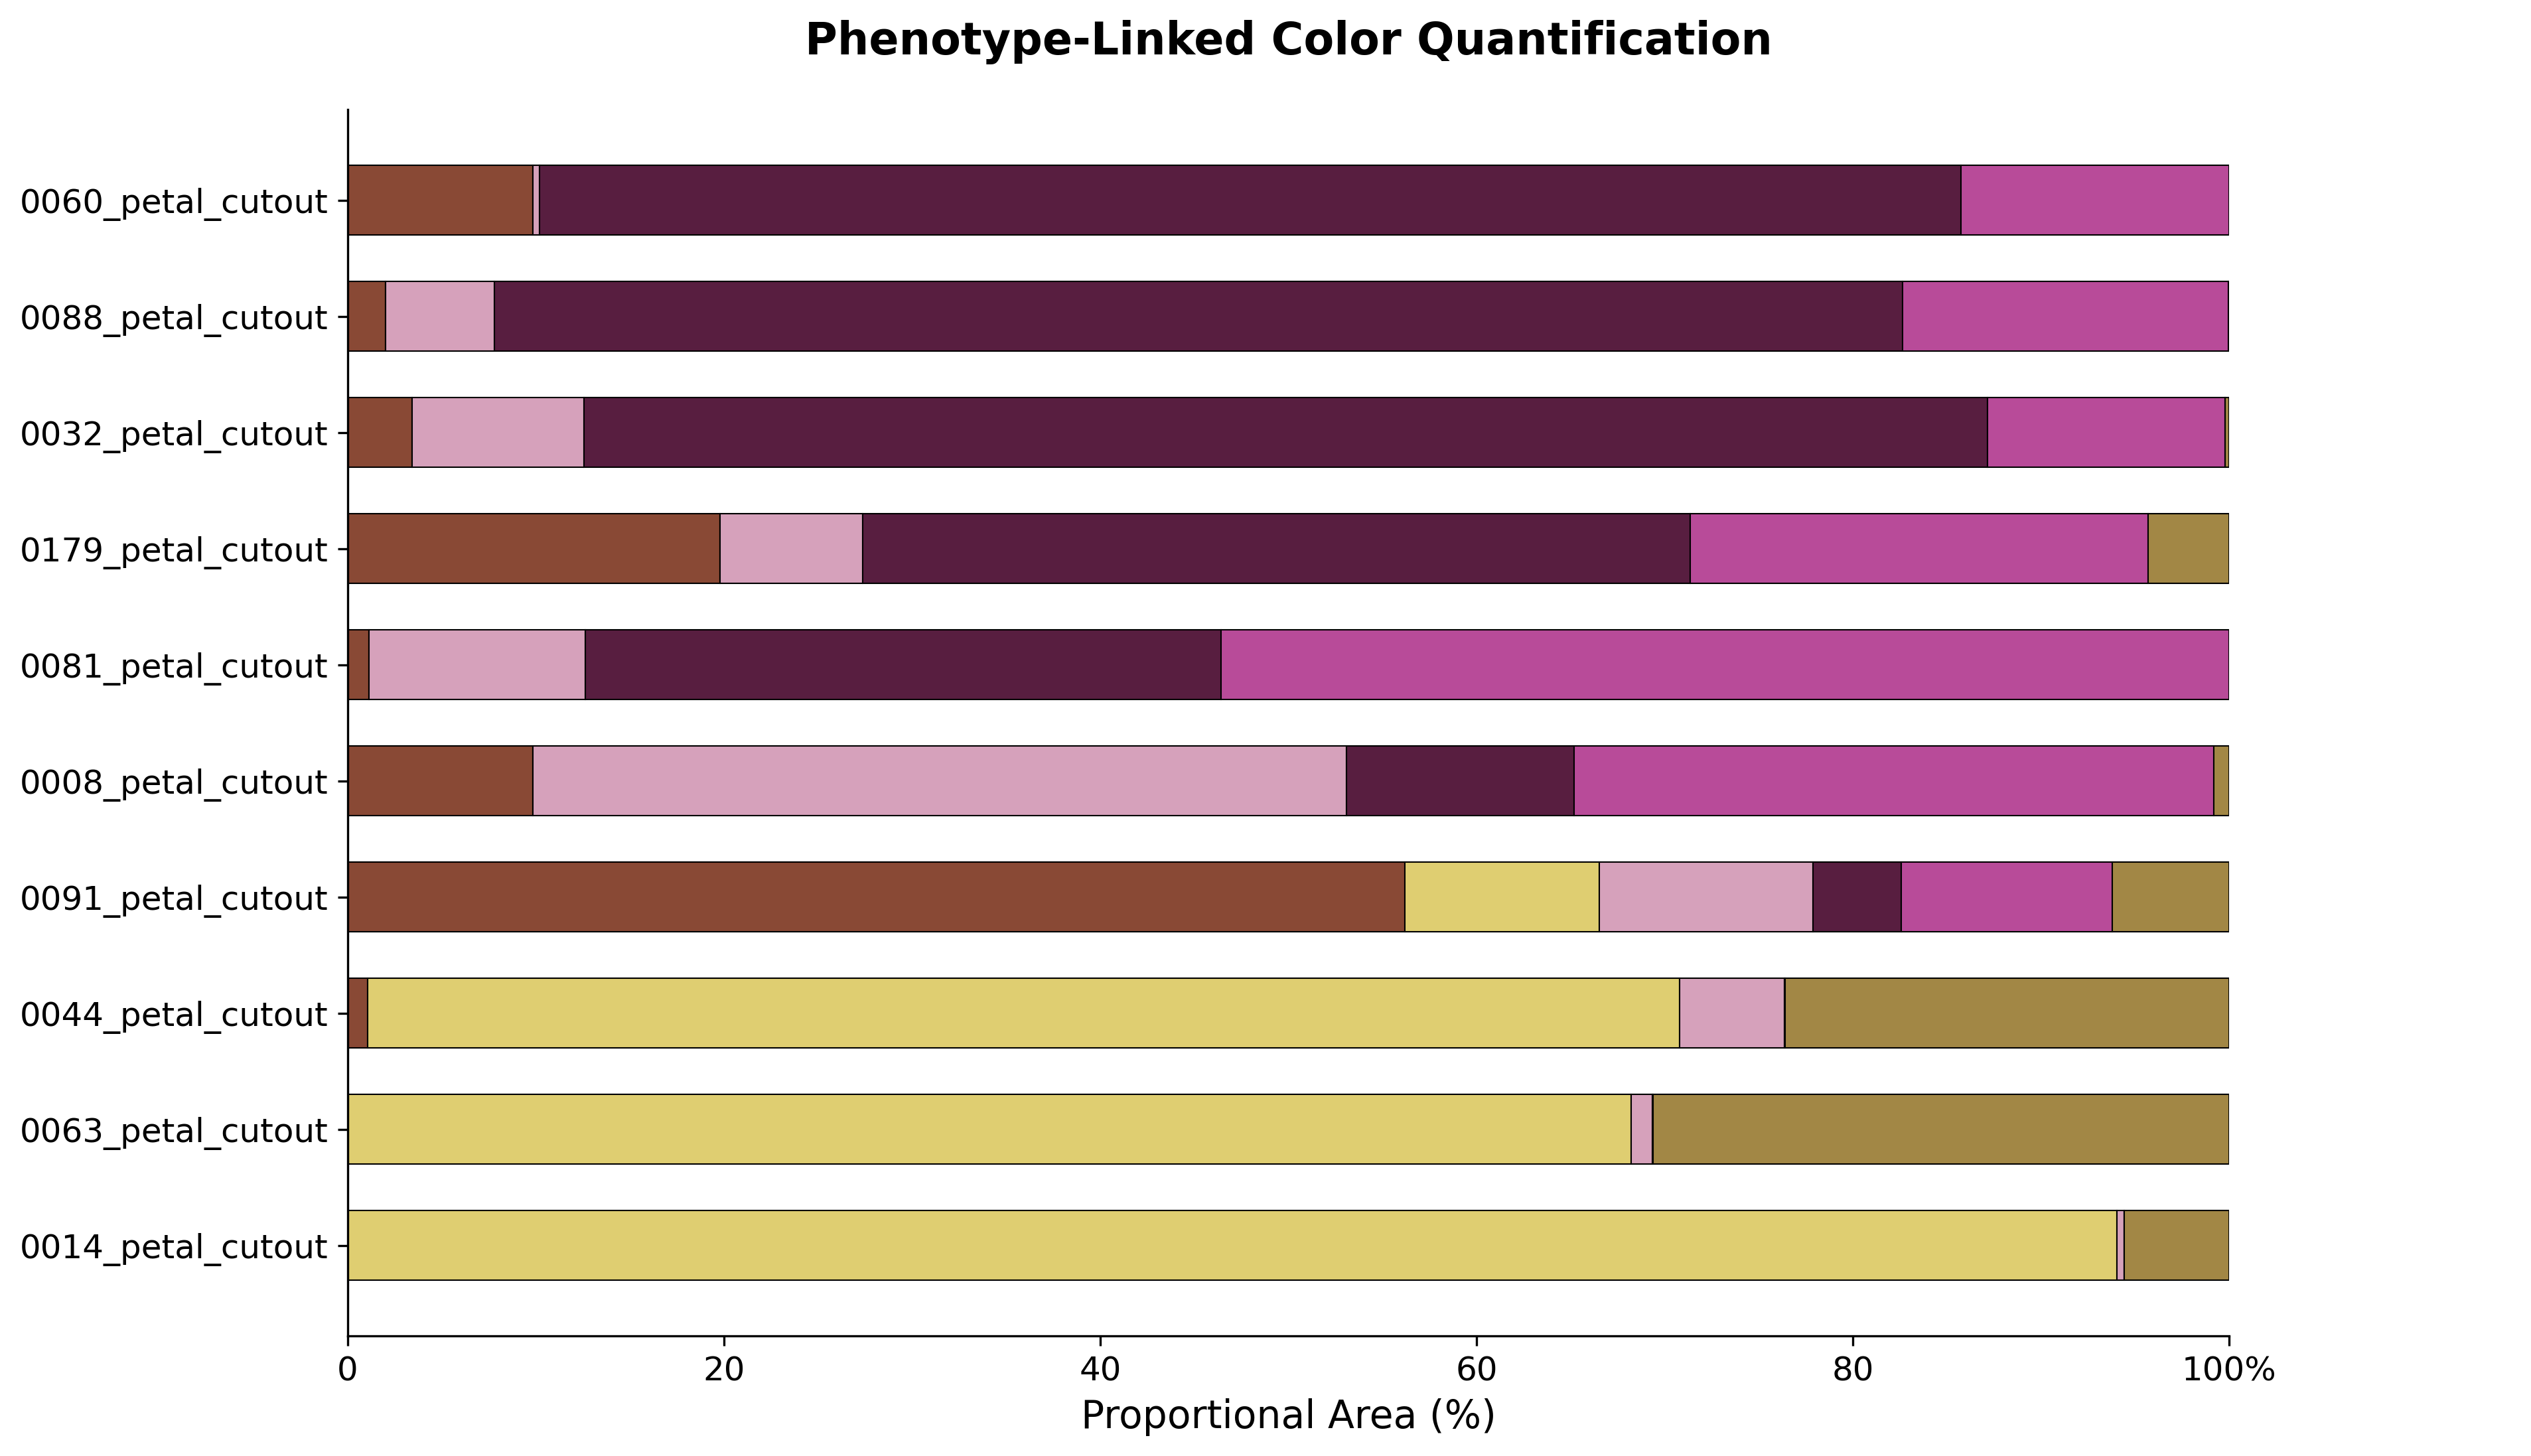

[✔] 完工！數據與圖表已全部封裝至 ./Pigment/


In [11]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from scipy.spatial.distance import cdist
import glob
import os

image_dir = './Datasets/color-plot/' 
output_dir = './Pigment'

print("[*] [Cell 4] 讀取官方標準尺進行推論...")
global_centers_lab = np.load(os.path.join(output_dir, "global_centers_lab.npy"))
global_centers_rgb = np.load(os.path.join(output_dir, "global_centers_rgb.npy"))

# 取前 12 張作為畫圖示範
test_image_paths = sorted(glob.glob(os.path.join(image_dir, '*.png')))[:12]
batch_features = []

for img_path in test_image_paths:
    filename = os.path.basename(img_path).replace('.png', '')
    img_bgr = cv2.imread(img_path)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    
    a_channel = img_lab[:,:,1].astype(np.float32) - 128
    b_channel = img_lab[:,:,2].astype(np.float32) - 128
    chroma = np.sqrt(a_channel**2 + b_channel**2)
    l_channel = img_lab[:,:,0]
    
    valid_mask = (l_channel > 15) & (chroma > 10) 
    valid_pixels_lab = img_lab[valid_mask]
    if len(valid_pixels_lab) == 0: continue
        
    distances = cdist(valid_pixels_lab, global_centers_lab, metric='euclidean')
    bin_ratios = np.bincount(np.argmin(distances, axis=1), minlength=len(global_centers_lab)) / len(valid_pixels_lab)
    
    feature_dict = {"Sample_ID": filename}
    for i in range(len(global_centers_lab)):
        feature_dict[f"Bin_{i}"] = bin_ratios[i]
    batch_features.append(feature_dict)

df_samples = pd.DataFrame(batch_features)
df_samples.to_csv(os.path.join(output_dir, "04_quantified_features.csv"), index=False)

# --- 繪製表現型對照圖 ---
print("[*] 正在生成發表級表現型對照圖...")
dominant_bin = df_samples.drop(columns=['Sample_ID']).mean().idxmax()
df_sorted = df_samples.sort_values(by=dominant_bin, ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
y_positions, left = np.arange(len(df_sorted)), np.zeros(len(df_sorted))
sample_labels = df_sorted['Sample_ID'].values

for i in range(len(global_centers_rgb)):
    ratios = df_sorted[f"Bin_{i}"].values
    ax.barh(y_positions, ratios, left=left, color=global_centers_rgb[i]/255.0, height=0.6, edgecolor='black', linewidth=0.5)
    left += ratios

for idx, sample_id in enumerate(sample_labels):
    img_bgr = cv2.imread(os.path.join(image_dir, f"{sample_id}.png"))
    if img_bgr is not None:
        img_rgba = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGBA)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        img_rgba[img_gray < 15, 3] = 0 # 黑底變透明
        
        h, w = img_rgba.shape[:2]
        img_thumb = cv2.resize(img_rgba, (int(w * (250/h)), 250))
        imagebox = OffsetImage(img_thumb, zoom=0.25)
        imagebox.image.axes = ax
        ax.add_artist(AnnotationBbox(imagebox, (1.02, y_positions[idx]), xycoords='data', box_alignment=(0, 0.5), frameon=False))

ax.set_title("Phenotype-Linked Color Quantification", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Proportional Area (%)", fontsize=14)
ax.set_yticks(y_positions)
ax.set_yticklabels(sample_labels, fontsize=12)
ax.set_xlim(0, 1.0); ax.set_xticks(np.arange(0, 1.1, 0.2)); ax.set_xticklabels(['0', '20', '40', '60', '80', '100%'], fontsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.subplots_adjust(right=0.8)

plt.savefig(os.path.join(output_dir, "05_phenotype_linked_barchart.png"), bbox_inches='tight')
plt.show()
print(f"[✔] 完工！數據與圖表已全部封裝至 {output_dir}/")

In [15]:
# Phase 6: Donut Chart Visualization
%run plot_color_donut.py


Detected K = 6 color bins
Saved: /home/nas2/Workspace/Aaron/2026-CIGR-phal-yolo-seg-quantify/packages/Quantification/Pigment/06_global_donut_chart.png
Saved: /home/nas2/Workspace/Aaron/2026-CIGR-phal-yolo-seg-quantify/packages/Quantification/Pigment/07_per_sample_donut_grid.png
Done!
